### 2.3 Spatio-Temporal Interplay
`demand_count` is shown jointly over (spatial unit × time). Three artefacts:

- Heatmap matrix: rows = top-N H3 r6 cells (or Community Areas), columns = hour of day, colour = mean `demand_count`
- Small multiples: four to six maps of Chicago at representative time slices (e.g. weekday 1am, 7am, 1pm, 7pm; vs. Saturday?), choropleth on the same spatial unit as 2.2
- Line plot: hourly demand profile for the top five hexagons over a typical day

The three artefacts exist because no single plot captures both dimensions well. The matrix is dense and exact but loses geography; the small multiples retain geography but lose continuity; the line plot makes the dynamics of individual hotspots readable.


In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
from matplotlib.collections import PolyCollection
import h3

PROCESSED = pathlib.Path("../processed")

def _load(name):
    return pd.read_parquet(PROCESSED / f"{name}.parquet")

agg_h3r6_total = _load("agg_h3r6_total")
agg_h3r6_dow_hour = _load("agg_h3r6_dow_hour")
agg_h3r6_dow_hour["n_trips"] = agg_h3r6_dow_hour["n_trips"].astype("int64")

calendar_counts = _load("calendar_counts")

TOTAL_DATES = int(calendar_counts["n_dates"].sum())
N_DATES = calendar_counts.set_index("day_of_week")["n_dates"].to_dict()

WEEKDAYS = [0, 1, 2, 3, 4]
WEEKEND = [5, 6]
DOW_NAMES = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

In [2]:
#Helper functions from notebook 2.1
def hex_polygon_xy(cell):
    return [(lng, lat) for (lat, lng) in h3.cell_to_boundary(cell)]


def draw_hex_choropleth(ax, cell_values, cmap="viridis", norm=None, title="", edgecolor="white"):
    polys, vals = [], []

    for cell, value in cell_values.items():
        polys.append(hex_polygon_xy(cell))
        vals.append(value)

    vals = np.asarray(vals, dtype=float)

    if norm is None:
        norm = Normalize(vmin=np.nanmin(vals), vmax=np.nanmax(vals))

    pc = PolyCollection(
        polys,
        array=vals,
        cmap=cmap,
        norm=norm,
        edgecolors=edgecolor,
        linewidths=0.3,
    )

    ax.add_collection(pc)
    ax.autoscale_view()
    ax.set_aspect(1 / np.cos(np.radians(41.88)))
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    return pc

def _norm(s):
    return s.astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

**2.3a — Heatmap matrix: top-N H3 r6 cells × hour of day**

Rows are the busiest r6 cells, columns are hour of day, colour is mean pickups per hour. A log
colour scale keeps the airport/Loop cells from flattening everything else.


In [3]:
print(agg_h3r6_dow_hour.dtypes)

h3_r6          category
day_of_week        int8
hour               int8
n_trips           int64
dtype: object


Top H3 r6 cells by demand:
  # 1  862664c1fffffff  (41.8794, -87.6055)   46.8%
  # 2  862759347ffffff  (42.0059, -87.9126)   20.7%
  # 3  862664c17ffffff  (41.9319, -87.6387)    6.6%
  # 4  862664cafffffff  (41.8866, -87.6855)    6.1%
  # 5  862664d8fffffff  (41.9844, -87.6720)    4.5%
  # 6  862664527ffffff  (41.7962, -87.7788)    3.0%
  # 7  862664cc7ffffff  (41.7817, -87.6191)    2.6%
  # 8  862664cf7ffffff  (41.8342, -87.6523)    2.3%
  # 9  862664ca7ffffff  (41.9391, -87.7188)    1.5%
  #10  862664ccfffffff  (41.7293, -87.5860)    1.1%
  #11  862664567ffffff  (41.6842, -87.6327)    0.8%
  #12  862664ce7ffffff  (41.8269, -87.5723)    0.7%


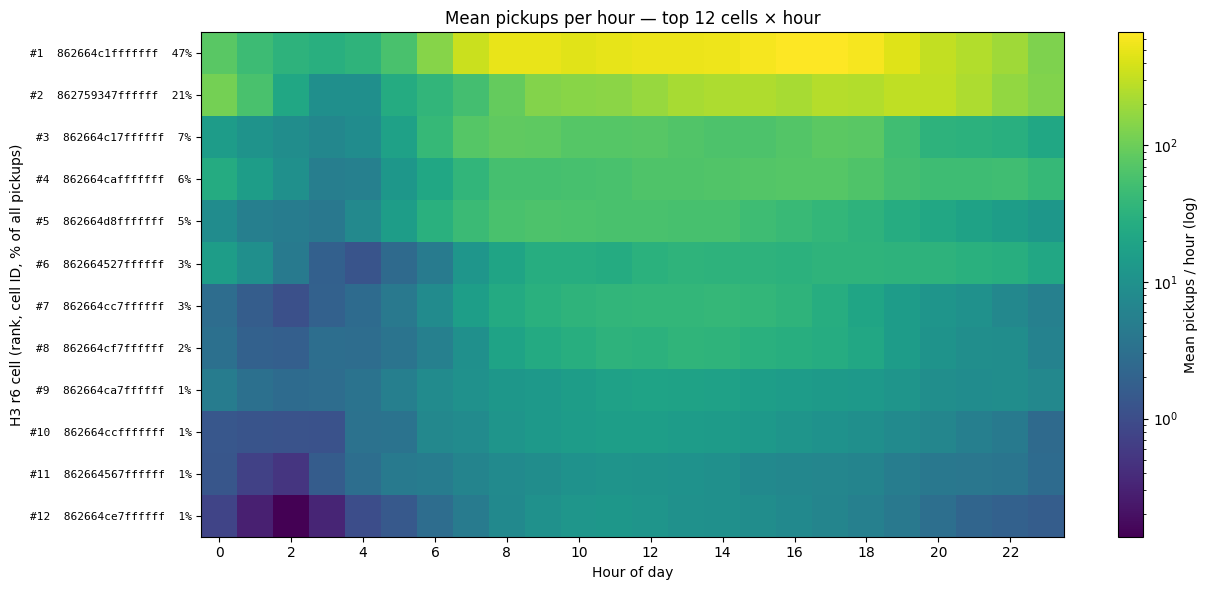

In [4]:
import h3

N_TOP = 12
cell_tot = agg_h3r6_dow_hour.groupby("h3_r6")["n_trips"].sum().sort_values(ascending=False)
top_cells = cell_tot.head(N_TOP).index.tolist()
total_all = cell_tot.sum()

# Label cells by rank, H3 cell ID, centroid coordinates, and share of all pickups
# (H3 cells are a uniform geometric grid — they do not correspond to city districts)
print("Top H3 r6 cells by demand:")
labels = []
for rank, c in enumerate(top_cells, 1):
    lat, lng = h3.cell_to_latlng(c)
    share = cell_tot[c] / total_all * 100
    print(f"  #{rank:>2}  {c}  ({lat:.4f}, {lng:.4f})  {share:5.1f}%")
    labels.append(f"#{rank}  {c}  {share:.0f}%")

# Mean pickups per hour-of-day
hour_of_day = (agg_h3r6_dow_hour.groupby(["h3_r6", "hour"])["n_trips"].sum()
               / TOTAL_DATES).rename("mean_demand").reset_index()
pivot = (hour_of_day[hour_of_day["h3_r6"].isin(top_cells)]
         .pivot(index="h3_r6", columns="hour", values="mean_demand")
         .reindex(index=top_cells, columns=range(24)).fillna(0)
         .astype("float64"))

# Heatmap
fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis",
               norm=LogNorm(vmin=max(pivot.values[pivot.values > 0].min(), 0.1),
                            vmax=pivot.values.max()))
ax.set_yticks(range(N_TOP)); ax.set_yticklabels(labels, fontsize=8, fontfamily="monospace")
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hour of day")
ax.set_ylabel("H3 r6 cell (rank, cell ID, % of all pickups)")
ax.set_title(f"Mean pickups per hour — top {N_TOP} cells × hour")
fig.colorbar(im, ax=ax, label="Mean pickups / hour (log)")
plt.tight_layout(); plt.show()

**2.3b — Small multiples: demand maps at representative time slices**

The spatial footprint of demand at four hours of a typical weekday, plus the same hours on
Saturday. All panels share one colour scale so they are directly comparable.


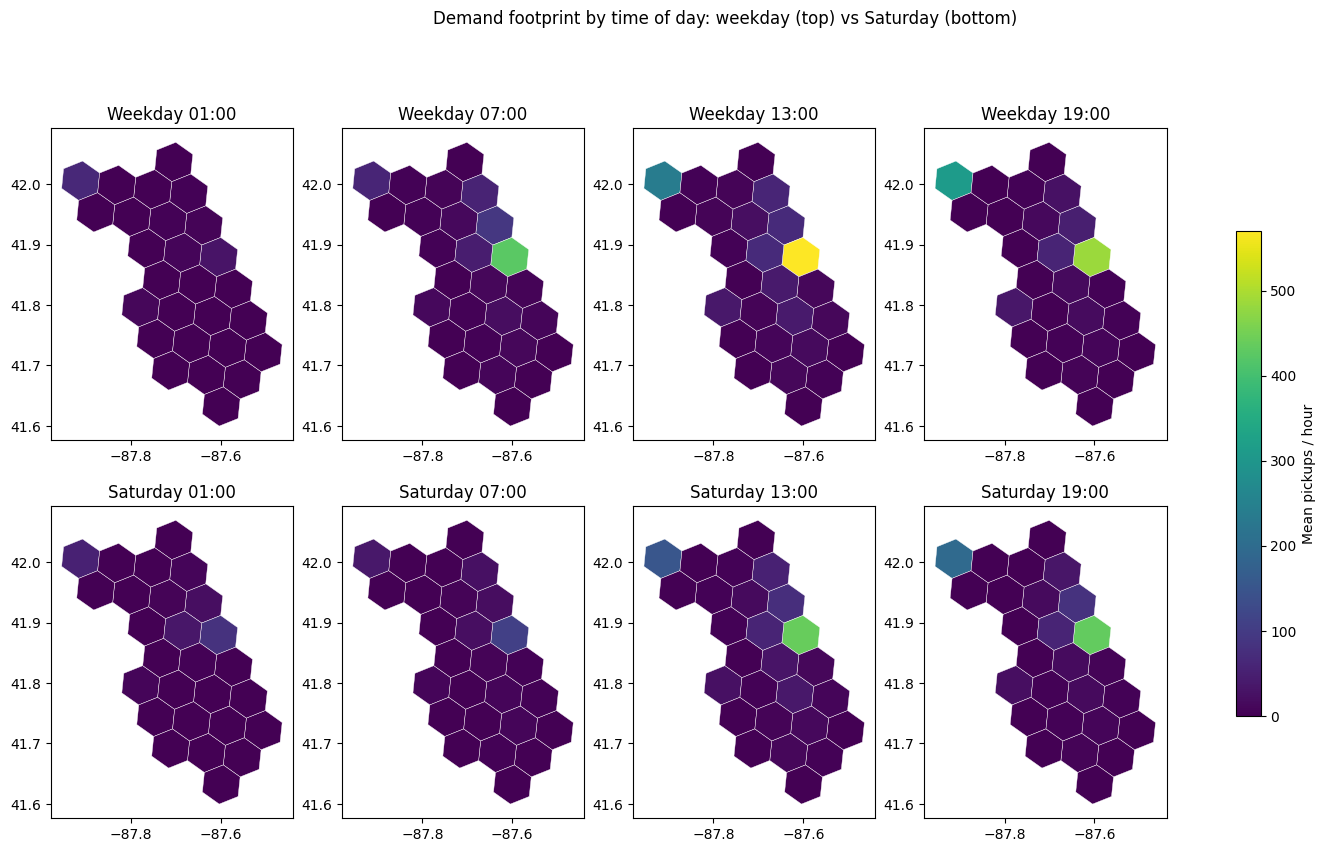

In [5]:
def cell_demand_at(hour, dows):
    sub = agg_h3r6_dow_hour[(agg_h3r6_dow_hour["hour"] == hour) &
                            (agg_h3r6_dow_hour["day_of_week"].isin(dows))]
    n_days = sum(N_DATES[d] for d in dows)
    s = sub.groupby("h3_r6")["n_trips"].sum() / n_days
    return s.to_dict()

slices = [(1, "01:00"), (7, "07:00"), (13, "13:00"), (19, "19:00")]
all_cells = agg_h3r6_total["h3_r6"].tolist()

# global vmax across all panels for a shared scale
panel_data = []
for h, lbl in slices:
    panel_data.append((f"Weekday {lbl}", cell_demand_at(h, WEEKDAYS)))
for h, lbl in slices:
    panel_data.append((f"Saturday {lbl}", cell_demand_at(h, [5])))
gmax = max((max(d.values()) if d else 0) for _, d in panel_data)
norm = Normalize(vmin=0, vmax=gmax)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (title, d) in zip(axes.ravel(), panel_data):
    full = {c: d.get(c, 0.0) for c in all_cells}   # show 0 for inactive cells
    pc = draw_hex_choropleth(ax, full, norm=norm, title=title, edgecolor="white")
    ax.set_xlabel(""); ax.set_ylabel("")
fig.colorbar(pc, ax=axes, label="Mean pickups / hour", shrink=0.7)
fig.suptitle("Demand footprint by time of day: weekday (top) vs Saturday (bottom)", y=1.01)
plt.show()


**2.3c — Hourly demand profile for the top five hexagons**

How the busiest cells rise and fall over a typical day. The airport cells peak differently from
the downtown cells — the operational reason small multiples and the matrix are complementary.


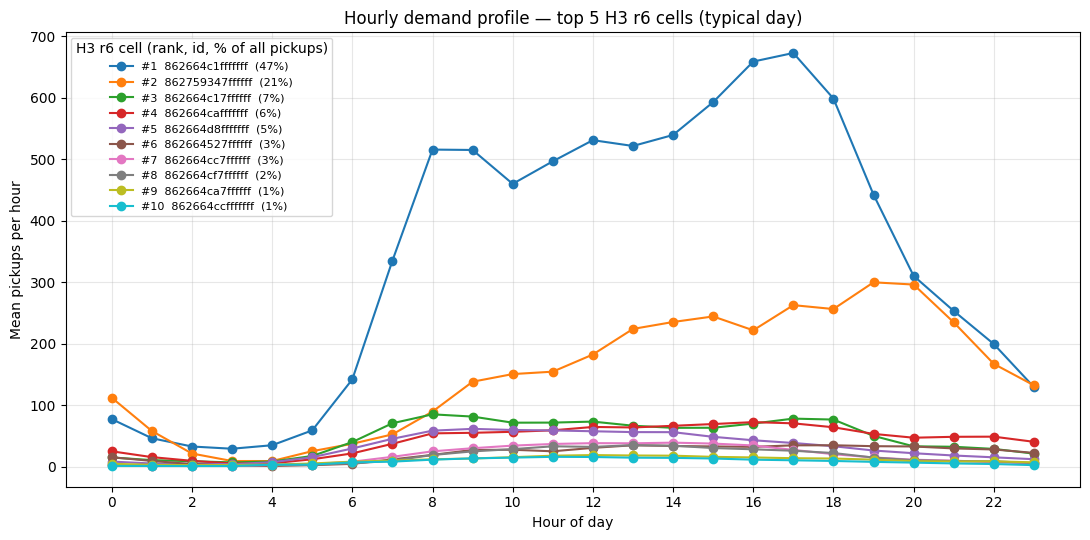

In [6]:
top5 = cell_tot.head(10).index.tolist()
total_all = cell_tot.sum()

fig, ax = plt.subplots(figsize=(11, 5.5))
for rank, c in enumerate(top5, 1):
    series = (hour_of_day[hour_of_day["h3_r6"] == c]
              .set_index("hour")["mean_demand"].reindex(range(24), fill_value=0))
    share = cell_tot[c] / total_all * 100
    ax.plot(series.index, series.values, marker="o",
            label=f"#{rank}  {c}  ({share:.0f}%)")
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean pickups per hour")
ax.set_title("Hourly demand profile — top 5 H3 r6 cells (typical day)")
ax.grid(True, alpha=0.3)
ax.legend(title="H3 r6 cell (rank, id, % of all pickups)", fontsize=8)
plt.tight_layout(); plt.show()

---
### Notes and limitations carried into later sections
- **Concentration:** a handful of r6 cells (Loop + airports) dominate all spatial views; log scales
  and top-N selection are used so the long tail stays visible.
- **Sampling:** GMM/KDE are *fitted* on coordinate samples for tractability; the full coordinate set
  is preserved upstream. Counts and choropleths use the complete data.
- **Community Area choropleth** needs an external boundary file (see 2.2b) — the only required
  output that depends on data outside the trip table.
- **Resolution** is previewed in 2.1e (1h vs 4h) and 2.2a (r6 vs r8); the systematic treatment is 2.7.


### 2.4 Origin-Destination Flows
Pickup → dropoff pairs are aggregated at Community Area level (H3 r6 produces too many low-volume pairs for a readable OD analysis). Required outputs:

- Top 20–50 OD pairs as a sorted table with trip count, mean trip distance and mean trip total
- Chord or Sankey diagram of the major flows (I don't even know what that is, but AI says it should be good)
- Asymmetry score per OD pair: `(forward − backward) / (forward + backward)`, used to flag corridors with structural repositioning need

Anchoring on pickups alone misses where vehicles end up after a trip, which is the relevant question for repositioning.

**2.4a — Top 30 OD pairs (Community Area level)**


In [7]:
agg_od_ca = _load("agg_od_ca")   # pickup_community_area, dropoff_community_area → n_trips, mean_trip_miles, mean_trip_total

def _norm_ca(s):
    """Normalise CA identifier strings: '32.0' → '32'."""
    return s.astype(str).str.replace(r"\.0$", "", regex=True).str.strip()

od = agg_od_ca.copy()
od["pickup_community_area"]  = _norm_ca(od["pickup_community_area"])
od["dropoff_community_area"] = _norm_ca(od["dropoff_community_area"])

top_od = (od.sort_values("n_trips", ascending=False)
            .head(30)
            .reset_index(drop=True))
top_od.index += 1

print(f"Total OD pairs with ≥1 trip: {len(od):,}")
display(
    top_od.style
      .format({"n_trips": "{:,.0f}",
               "mean_trip_miles": "{:.2f}",
               "mean_trip_total": "${:.2f}"})
      .background_gradient(subset=["n_trips"], cmap="Blues")
      .set_caption("Top 30 Origin → Destination pairs by trip count (Community Area level)"))


Total OD pairs with ≥1 trip: 5,705


,pickup_community_area,dropoff_community_area,n_trips,mean_trip_miles,mean_trip_total
1,8,8,"1,111,175",0.83,$11.62
2,32,8,"686,878",1.34,$10.42
3,8,32,"648,960",1.34,$10.49
4,76,8,"589,805",17.09,$58.91
5,32,32,"584,897",0.73,$12.32
6,28,8,"417,667",1.79,$11.64
7,8,28,"392,735",1.98,$12.32
8,76,32,"377,834",17.69,$61.02
9,28,32,"370,969",1.11,$9.23
10,32,28,"356,451",1.34,$10.14


**2.4b — Sankey diagram of major flows**

Within-area trips (pickup CA == dropoff CA) are excluded — they are real trips but not inter-area corridors.
Top 15 Community Areas by outbound volume are shown; flows between them only.
Left side = pickup (origin), right side = dropoff (destination).


In [8]:
od_inter = od[od["pickup_community_area"] != od["dropoff_community_area"]].copy()

TOP_CA = 10

top_cas = (od_inter.groupby("pickup_community_area")["n_trips"].sum()
                   .sort_values(ascending=False).head(TOP_CA).index.tolist())
od_top = od_inter[od_inter["pickup_community_area"].isin(top_cas) &
                  od_inter["dropoff_community_area"].isin(top_cas)].copy()


import plotly.graph_objects as go

n = len(top_cas)
# Same CA label appears twice (left = pickup, right = dropoff)
src_idx = {c: i     for i, c in enumerate(top_cas)}
dst_idx = {c: i + n for i, c in enumerate(top_cas)}
labels  = [f"CA {c}" for c in top_cas] + [f"CA {c}" for c in top_cas]

fig_s = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(pad=12, thickness=18, label=labels),
    link=dict(
        source=od_top["pickup_community_area"].map(src_idx).tolist(),
        target=od_top["dropoff_community_area"].map(dst_idx).tolist(),
        value =od_top["n_trips"].tolist(),
    ),
))
fig_s.update_layout(
    title_text=(f"OD flows — top {TOP_CA} Community Areas "
                f"(left = pickup origin, right = dropoff destination)"),
    font_size=10, height=600,
)
fig_s.show()



**2.4c — Asymmetry score per corridor**

For every directed corridor A → B, the reverse flow B → A is looked up.
`asymmetry = (A→B − B→A) / (A→B + B→A)` — equals +1 when fully one-directional, 0 when perfectly balanced.
High asymmetry = taxis arrive but cannot find a return trip → repositioning cost.


,pickup_community_area,dropoff_community_area,n_trips,n_reverse,asymmetry
1,76,7,"139,254","18,194",+0.769
2,76,28,"133,201","19,566",+0.744
3,76,6,"149,432","26,343",+0.700
4,76,8,"589,805","155,297",+0.583
5,76,32,"377,834","121,399",+0.514
6,8,7,"172,244","97,245",+0.278
7,8,6,"143,109","108,786",+0.136
8,32,33,"136,951","118,108",+0.074
9,28,8,"417,667","392,735",+0.031
10,32,8,"686,878","648,960",+0.028


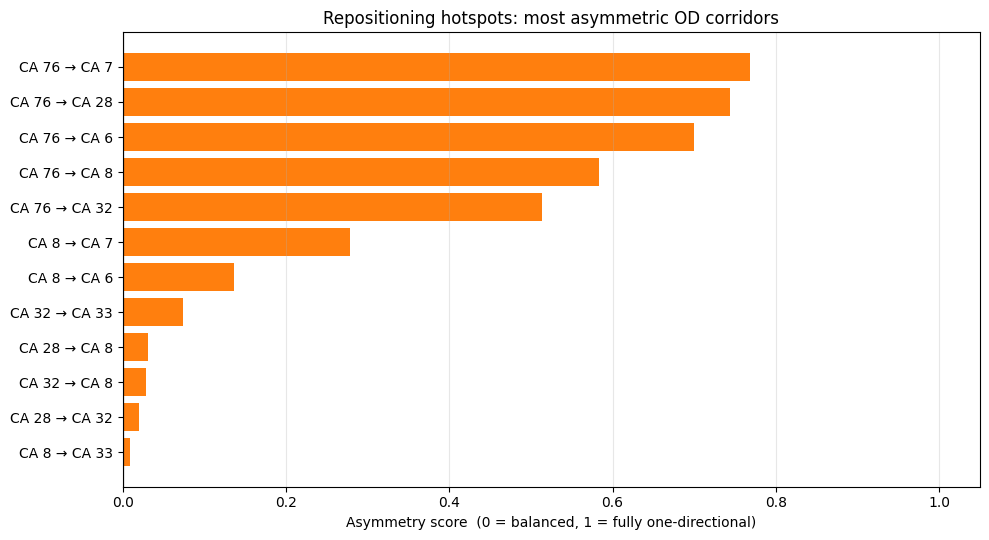

In [9]:
MIN_TRIPS = 100000

# For every directed pair (A→B), look up the reverse volume (B→A)
od_rev = od_inter[["pickup_community_area", "dropoff_community_area", "n_trips"]].rename(
    columns={"pickup_community_area":  "dropoff_community_area",
             "dropoff_community_area": "pickup_community_area",
             "n_trips":               "n_reverse"})
od_a = od_inter.merge(od_rev, on=["pickup_community_area", "dropoff_community_area"], how="left")
od_a["n_reverse"] = od_a["n_reverse"].fillna(0).astype(int)
od_a["asymmetry"] = (od_a["n_trips"] - od_a["n_reverse"]) / (od_a["n_trips"] + od_a["n_reverse"])

# Keep only the dominant direction (n_trips > n_reverse) and filter sparse corridors 
od_a = od_a[(od_a["n_trips"] > od_a["n_reverse"]) & (od_a["n_trips"] >= MIN_TRIPS)]
top_asym = od_a.sort_values("asymmetry", ascending=False).head(15).reset_index(drop=True)
top_asym.index += 1

display(
    top_asym[["pickup_community_area", "dropoff_community_area",
              "n_trips", "n_reverse", "asymmetry"]]
    .style
    .format({"n_trips": "{:,.0f}", "n_reverse": "{:,.0f}", "asymmetry": "{:+.3f}"})
    .background_gradient(subset=["asymmetry"], cmap="Oranges")
    .set_caption("Top 15 asymmetric corridors. Score +1 = fully one-directional → taxi must reposition."))

labels = [f"CA {r['pickup_community_area']} → CA {r['dropoff_community_area']}"
          for _, r in top_asym.iterrows()]
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(labels[::-1], top_asym["asymmetry"].values[::-1], color="tab:orange")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Asymmetry score  (0 = balanced, 1 = fully one-directional)")
ax.set_title("Repositioning hotspots: most asymmetric OD corridors")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout(); plt.show()


### 2.5 External Drivers: Weather
The hourly weather data from Section 1.5 is merged onto the hourly demand aggregate by `timestamp_h`. Required outputs:

- `demand_count` vs. `temp_h`, binned and plotted with median and IQR per bin
- Same for `precip_h` and `snow_h`
- Comparison of rainy vs. dry days at the same hour of day, to control for the time-of-day confound (rain peaks in the afternoon, demand also peaks in the afternoon — a raw correlation would mostly capture this)
- in generel problem of analyzing temp e.g., because this correlates with time => so try to cancel time-influence and look at data always at 4pm e.g. with different temps. 

Snowfall is analysed only for the winter months; outside winter the signal is too sparse. Weather has only a temporal component, so all comparisons here are city-level.

**2.5 Setup: city-level 4h demand series with weather**

`df_agg_r6_4h` contains demand per H3 r6 cell per 4-hour slot with weather already attached.
Summing across all cells per timestamp gives city-wide demand at 4h resolution.
Weather variables are identical for all cells at the same timestamp, so `first` is used.


In [10]:
df_agg_r6_4h = _load("df_agg_r6_4h")

# Aggregate all H3 cells → city-level demand per 4h slot; weather is same for all cells
city_4h = (
    df_agg_r6_4h
    .groupby("timestamp", as_index=False)
    .agg(
        demand_count=("demand_count", "sum"),
        temp_4h     =("temp_4h",     "first"),
        rain_4h     =("rain_4h",     "first"),
        snow_4h     =("snow_4h",     "first"),
        precip_4h   =("precip_4h",   "first"),
    )
)
city_4h["hour"]      = city_4h["timestamp"].dt.hour
city_4h["month"]     = city_4h["timestamp"].dt.month
city_4h["is_winter"] = city_4h["month"].isin([11, 12, 1, 2, 3])
city_4h["is_rainy"]  = city_4h["rain_4h"] > 0
city_4h["is_snowy"]  = city_4h["snow_4h"] > 0

print(f"City-level 4h slots: {len(city_4h):,}")
print(f"Temperature range : {city_4h['temp_4h'].min():.1f}°F  –  {city_4h['temp_4h'].max():.1f}°F")
print(f"Rainy slots        : {city_4h['is_rainy'].sum():,}  ({city_4h['is_rainy'].mean()*100:.1f}%)")
print(f"Snowy slots (total): {city_4h['is_snowy'].sum():,}  | winter only: {city_4h[city_4h['is_winter']]['is_snowy'].sum():,}")


City-level 4h slots: 4,927
Temperature range : -12.3°F  –  96.3°F
Rainy slots        : 885  (18.0%)
Snowy slots (total): 271  | winter only: 262


**2.5a — Demand vs temperature**

**Problem:** temperature correlates with time of day. Warmer temperatures are more common during daytime, when taxi demand is also higher. Therefore, a raw binned plot may partly capture the daily demand cycle instead of a pure temperature effect.

**Fix:** demand is normalized by the typical demand of the same 4-hour slot. This keeps all observations but reduces the time-of-day confound.

Both views are shown side-by-side: raw demand vs. temperature and hour-controlled demand vs. temperature.

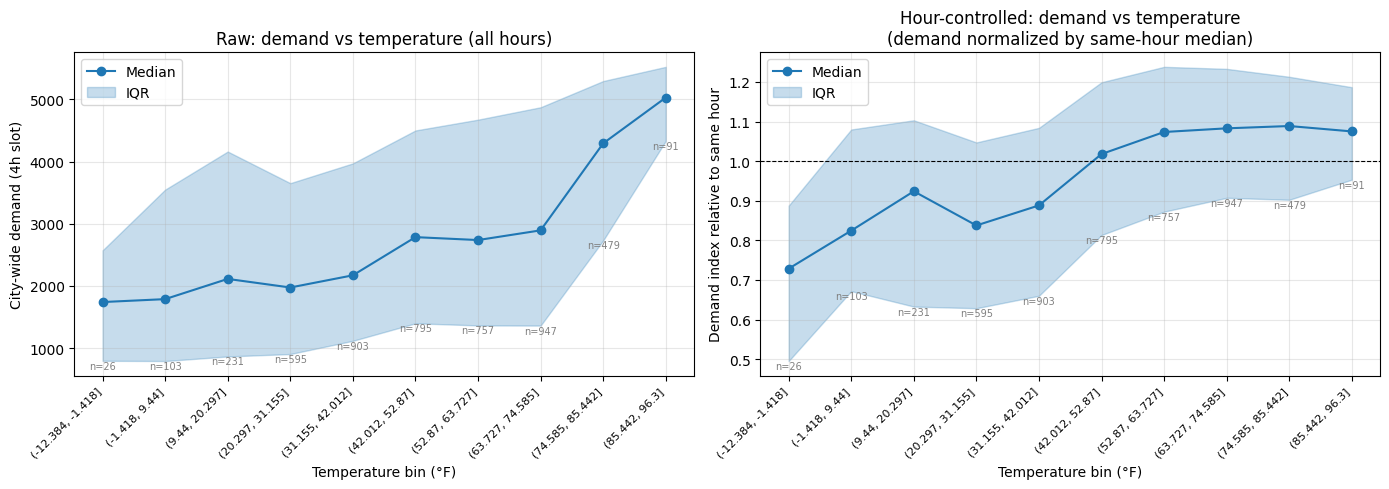

In [11]:
N_BINS = 10
city_4h = city_4h.copy()

# Bin temperature
city_4h["temp_bin"] = pd.cut(city_4h["temp_4h"], bins=N_BINS)

def binned_stats(df, bin_col, val_col):
    g = df.groupby(bin_col, observed=True)[val_col]
    return pd.DataFrame({
        "median": g.median(),
        "q25":    g.quantile(0.25),
        "q75":    g.quantile(0.75),
        "n":      g.count(),
    })

# Raw relationship: demand vs temperature, all hours
stats_all = binned_stats(city_4h, "temp_bin", "demand_count")

# Hour-controlled relationship:
# Normalize demand by the typical demand at the same hour of day.
# This keeps all hours but reduces the time-of-day confound.
city_4h["hour_median_demand"] = city_4h.groupby("hour")["demand_count"].transform("median")
city_4h["demand_index"] = city_4h["demand_count"] / city_4h["hour_median_demand"]

stats_hour_controlled = binned_stats(city_4h, "temp_bin", "demand_index")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_specs = [
    (
        axes[0],
        stats_all,
        "Raw: demand vs temperature (all hours)",
        "City-wide demand (4h slot)"
    ),
    (
        axes[1],
        stats_hour_controlled,
        "Hour-controlled: demand vs temperature\n(demand normalized by same-hour median)",
        "Demand index relative to same hour"
    ),
]

for ax, stats, title, ylabel in plot_specs:
    xs = range(len(stats))

    ax.plot(xs, stats["median"], marker="o", color="tab:blue", label="Median")
    ax.fill_between(
        xs,
        stats["q25"],
        stats["q75"],
        alpha=0.25,
        color="tab:blue",
        label="IQR"
    )

    ax.set_xticks(xs)
    ax.set_xticklabels(
        [str(b) for b in stats.index],
        rotation=45,
        ha="right",
        fontsize=8
    )

    ax.set_xlabel("Temperature bin (°F)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Annotate n per bin
    for x, n in zip(xs, stats["n"]):
        ax.text(
            x,
            stats["q25"].iloc[x],
            f"n={n}",
            ha="center",
            va="top",
            fontsize=7,
            color="grey"
        )

# Reference line for normalized demand
axes[1].axhline(1, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.show()

**2.5b — Demand vs precipitation (rain)**

Same hour-of-day confound applies: rain peaks in the afternoon when demand is already high.
Fix: compare rainy vs dry slots **at the same hour of day** — so for each hour we compare
the average demand on rainy vs dry slots. The ratio shows the pure rain lift.


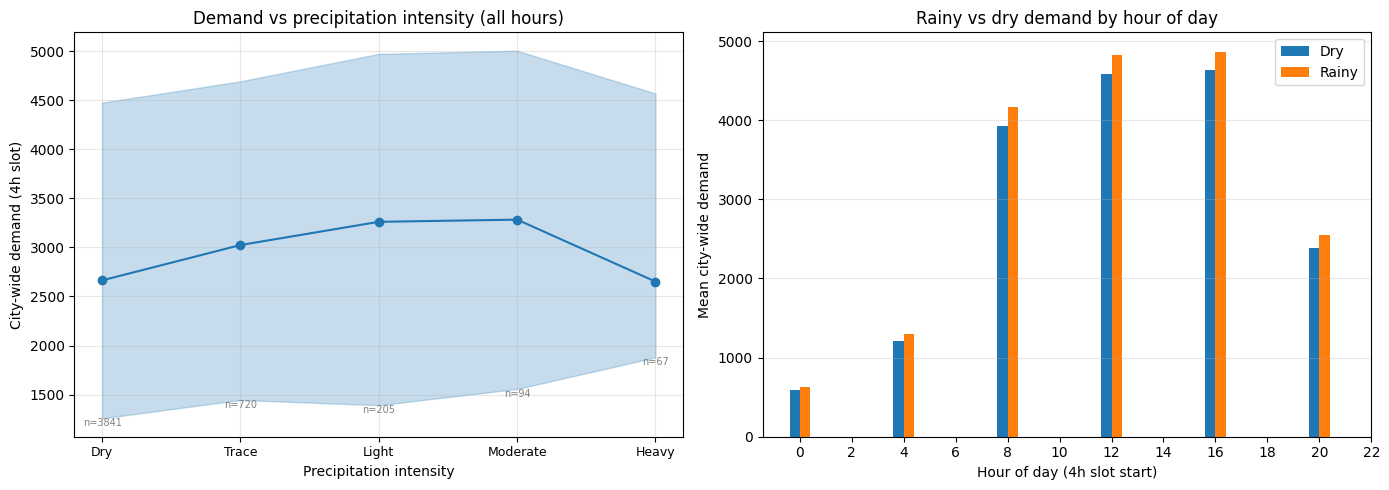

Mean rain demand lift across all hours: +6.1%
is_rainy     Dry   Rainy  rain_lift_%
hour                                 
0          593.7   630.2          6.1
4         1212.9  1302.0          7.3
8         3932.7  4161.1          5.8
12        4579.9  4820.9          5.3
16        4628.4  4866.7          5.1
20        2380.8  2547.4          7.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: binned rain intensity vs demand (raw)
precip_bins = pd.cut(city_4h["precip_4h"], bins=[-0.001, 0, 0.05, 0.15, 0.3, np.inf],
                     labels=["Dry", "Trace", "Light", "Moderate", "Heavy"])
city_4h["precip_bin"] = precip_bins
stats_precip = binned_stats(city_4h, "precip_bin", "demand_count")
xs = range(len(stats_precip))
axes[0].plot(xs, stats_precip["median"], marker="o", color="tab:blue")
axes[0].fill_between(xs, stats_precip["q25"], stats_precip["q75"], alpha=0.25, color="tab:blue")
axes[0].set_xticks(xs); axes[0].set_xticklabels(stats_precip.index, fontsize=9)
axes[0].set_xlabel("Precipitation intensity"); axes[0].set_ylabel("City-wide demand (4h slot)")
axes[0].set_title("Demand vs precipitation intensity (all hours)")
axes[0].grid(True, alpha=0.3)
for x, n in zip(xs, stats_precip["n"]):
    axes[0].text(x, stats_precip["q25"].iloc[x], f"n={n}", ha="center", va="top", fontsize=7, color="grey")

# Right: rainy vs dry per hour (hour-controlled comparison)
pivot_rain = (city_4h.groupby(["hour", "is_rainy"])["demand_count"]
                .mean().unstack("is_rainy").rename(columns={False: "Dry", True: "Rainy"}))
pivot_rain["rain_lift_%"] = (pivot_rain["Rainy"] / pivot_rain["Dry"] - 1) * 100

ax2 = axes[1]
ax2.bar(pivot_rain.index - 0.2, pivot_rain["Dry"],   width=0.4, label="Dry",   color="tab:blue")
ax2.bar(pivot_rain.index + 0.2, pivot_rain["Rainy"], width=0.4, label="Rainy", color="tab:orange")
ax2.set_xticks(range(0, 24, 2)); ax2.set_xlabel("Hour of day (4h slot start)")
ax2.set_ylabel("Mean city-wide demand"); ax2.set_title("Rainy vs dry demand by hour of day")
ax2.grid(True, axis="y", alpha=0.3); ax2.legend()

plt.tight_layout(); plt.show()

# Summary: average rain lift across all hours
mean_lift = pivot_rain["rain_lift_%"].mean()
print(f"Mean rain demand lift across all hours: {mean_lift:+.1f}%")
print(pivot_rain[["Dry","Rainy","rain_lift_%"]].round(1).to_string())


**2.5c — Demand vs snowfall (winter months only)**

Snow events are sparse outside Nov–Mar; restricting to winter prevents near-zero-count bins from
dominating the comparison. Same hour-controlled approach as precipitation.


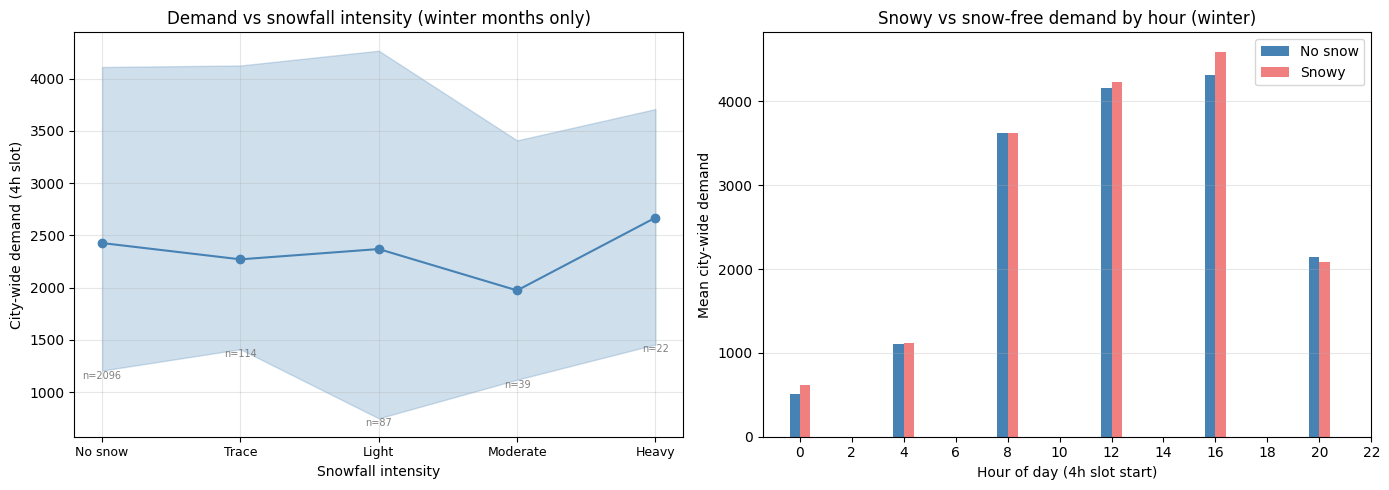

Mean snow demand lift across winter hours: +4.4%


In [13]:
winter = city_4h[city_4h["is_winter"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: binned snow intensity vs demand
snow_bins = pd.cut(winter["snow_4h"], bins=[-0.001, 0, 0.1, 0.3, 0.7, np.inf],
                   labels=["No snow", "Trace", "Light", "Moderate", "Heavy"])
winter["snow_bin"] = snow_bins
stats_snow = binned_stats(winter, "snow_bin", "demand_count")
xs = range(len(stats_snow))
axes[0].plot(xs, stats_snow["median"], marker="o", color="steelblue")
axes[0].fill_between(xs, stats_snow["q25"], stats_snow["q75"], alpha=0.25, color="steelblue")
axes[0].set_xticks(xs); axes[0].set_xticklabels(stats_snow.index, fontsize=9)
axes[0].set_xlabel("Snowfall intensity"); axes[0].set_ylabel("City-wide demand (4h slot)")
axes[0].set_title("Demand vs snowfall intensity (winter months only)")
axes[0].grid(True, alpha=0.3)
for x, n in zip(xs, stats_snow["n"]):
    axes[0].text(x, stats_snow["q25"].iloc[x], f"n={n}", ha="center", va="top", fontsize=7, color="grey")

# Right: snowy vs no-snow per hour (hour-controlled)
pivot_snow = (winter.groupby(["hour", "is_snowy"])["demand_count"]
                .mean().unstack("is_snowy").rename(columns={False: "No snow", True: "Snowy"}))
pivot_snow["snow_lift_%"] = (pivot_snow["Snowy"] / pivot_snow["No snow"] - 1) * 100

ax2 = axes[1]
ax2.bar(pivot_snow.index - 0.2, pivot_snow["No snow"], width=0.4, label="No snow", color="steelblue")
ax2.bar(pivot_snow.index + 0.2, pivot_snow["Snowy"],   width=0.4, label="Snowy",   color="lightcoral")
ax2.set_xticks(range(0, 24, 2)); ax2.set_xlabel("Hour of day (4h slot start)")
ax2.set_ylabel("Mean city-wide demand"); ax2.set_title("Snowy vs snow-free demand by hour (winter)")
ax2.grid(True, axis="y", alpha=0.3); ax2.legend()

plt.tight_layout(); plt.show()

mean_snow_lift = pivot_snow["snow_lift_%"].mean()
print(f"Mean snow demand lift across winter hours: {mean_snow_lift:+.1f}%")


### 2.6 Spatial Variation in Trip Characteristics

For each Community Area, selected per-area trip characteristics are computed and visualised as choropleths:

- mean trip distance
- mean trip duration
- mean trip total
- mean speed
- mean price per mile
- median idle time
- number of distinct companies operating in the area
- share of digital payments
- mean tip rate

2.2 counts pickups; 2.6 describes what those pickups produce. Two areas can show similar demand volumes but differ substantially in trip economics, payment behaviour, speed and idle time. These differences are relevant for fleet sizing, positioning and revenue expectations.

**2.6 Setup — compute per-CA trip characteristics**

In [14]:
# Load only the columns needed 
_cols = ["pickup_community_area", "trip_miles", "trip_seconds", "trip_total",
         "fare", "tips", "payment_type", "company", "avg_speed_mph",
         "price_per_mile"]
trips = pd.read_parquet(PROCESSED / "df_trips_full.parquet", columns=_cols)
trips = trips.dropna(subset=["pickup_community_area"])

DIGITAL_PAYMENTS = {"Credit Card", "Mobile"}
trips["is_digital"] = trips["payment_type"].isin(DIGITAL_PAYMENTS)
trips["tip_rate"]   = (trips["tips"] / trips["fare"]).where(trips["fare"].fillna(0) > 0)
trips["trip_mins"]  = trips["trip_seconds"] / 60

ca_chars = trips.groupby("pickup_community_area", observed=True).agg(
    n_trips            = ("trip_miles",    "size"),
    mean_trip_miles    = ("trip_miles",    "mean"),
    mean_trip_mins     = ("trip_mins",     "mean"),
    mean_trip_total    = ("trip_total",    "mean"),
    mean_speed_mph     = ("avg_speed_mph", "mean"),
    mean_price_per_mile= ("price_per_mile","mean"),
    digital_share      = ("is_digital",    "mean"),
    mean_tip_rate      = ("tip_rate",      "mean"),
    n_companies        = ("company",       "nunique"),
).reset_index()

# Normalise CA key ("32.0" → "32") to match the GeoJSON key
ca_chars["pickup_community_area"] = _norm(ca_chars["pickup_community_area"].astype(str))

del trips   # ( for my bad RAM...)

idle = pd.read_parquet(PROCESSED / "idle_per_trip.parquet",
                       columns=["pickup_community_area", "idle_seconds"])
idle = idle.dropna(subset=["pickup_community_area"])
idle["pickup_community_area"] = _norm(idle["pickup_community_area"].astype(str))
ca_idle = (idle.groupby("pickup_community_area")["idle_seconds"]
               .median().rename("median_idle_mins").reset_index())
ca_idle["median_idle_mins"] /= 60
del idle

ca_chars = ca_chars.merge(ca_idle, on="pickup_community_area", how="left")
print(f"Trip characteristics computed for {len(ca_chars)} community areas")
print(ca_chars.describe().T[["mean", "min", "max"]].round(2))


Trip characteristics computed for 77 community areas
                              mean       min        max
n_trips              186692.454545    1817.0  3258311.0
mean_trip_miles           7.769789  2.049663  14.247132
mean_trip_mins           44.210386  21.04179  70.673107
mean_trip_total          26.736401  9.773081  54.526066
mean_speed_mph           25.404305  8.042819  45.024139
mean_price_per_mile      14.374603  4.846143  91.548576
digital_share             0.194492  0.005886   0.792668
mean_tip_rate             0.042226  0.002326   0.190295
n_companies              31.324675      15.0       44.0
median_idle_mins         21.038961      15.0       90.0


**2.6a — Multi-panel choropleth**

In [15]:
metric_panels = [
    ("mean_trip_miles",     "Mean trip distance (mi)",      "YlOrRd"),
    ("mean_trip_mins",      "Mean trip duration (min)",     "YlOrBr"),
    ("mean_speed_mph",      "Mean speed (mph)",             "RdYlGn"),
    ("mean_trip_total",     "Mean trip total ($)",          "Purples"),
    ("mean_price_per_mile", "Mean price per mile ($/mi)",   "PuBuGn"),
    ("digital_share",       "Digital payment share",        "Blues"),
    ("mean_tip_rate",       "Mean tip rate",                "Greens"),
    ("median_idle_mins",    "Median idle time (min)",       "Oranges"),
]

if "gdf" in dir():
    gdf_chars = gdf[["_key", "geometry"]].merge(
        ca_chars, left_on="_key", right_on="pickup_community_area", how="left"
    )

    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    for ax, (col, title, cmap) in zip(axes.ravel(), metric_panels):
        gdf_chars.plot(
            column=col, ax=ax, cmap=cmap, legend=True,
            missing_kwds={"color": "lightgrey", "label": "No data"},
            edgecolor="white", linewidth=0.3,
        )
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_axis_off()

    fig.suptitle("2.6 — Spatial Variation in Trip Characteristics by Community Area",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("gdf not available — run the Community Area choropleth cell in 2.2b first.")


gdf not available — run the Community Area choropleth cell in 2.2b first.


**2.6b — Ranked highlights: which areas stand out?**

The choropleths show spatial structure; bar charts below show which Community Areas sit at the
extremes of each metric — useful for fleet operators deciding where to position vehicles.


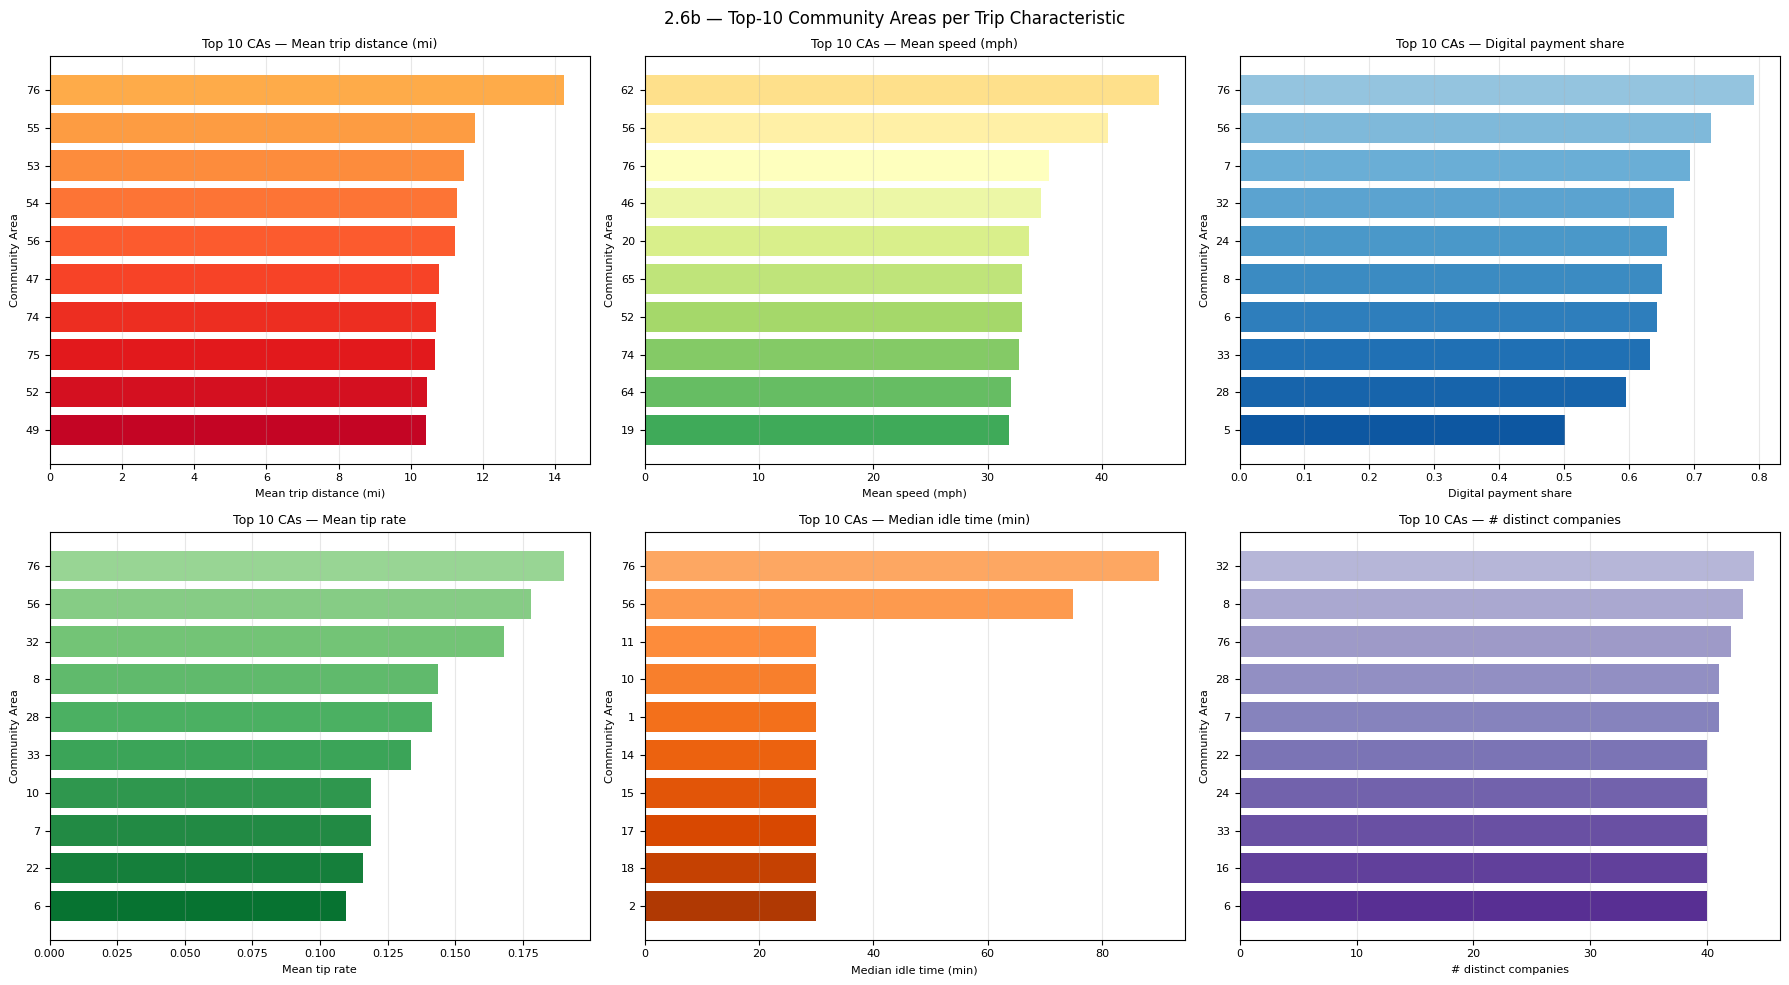


Summary: Top-5 CAs per metric
------------------------------------------------------------

Mean trip distance (mi):
CA  mean_trip_miles
76        14.247132
55        11.782058
53        11.476191
54        11.277612
56        11.220048

Mean speed (mph):
CA  mean_speed_mph
62       45.024139
56       40.530937
76       35.381676
46       34.652645
20       33.597881

Digital payment share:
CA  digital_share
76       0.792668
56       0.726616
 7       0.693289
32       0.668507
24       0.658388

Mean tip rate:
CA  mean_tip_rate
76       0.190295
56       0.177992
32       0.168041
 8       0.143744
28       0.141353

Median idle time (min):
CA  median_idle_mins
76              90.0
56              75.0
 1              30.0
10              30.0
11              30.0

# distinct companies:
CA  n_companies
32           44
 8           43
76           42
28           41
 7           41


In [16]:
TOP_N = 10

highlight_metrics = [
    ("mean_trip_miles",     "Mean trip distance (mi)",    "YlOrRd"),
    ("mean_speed_mph",      "Mean speed (mph)",           "RdYlGn"),
    ("digital_share",       "Digital payment share",      "Blues"),
    ("mean_tip_rate",       "Mean tip rate",              "Greens"),
    ("median_idle_mins",    "Median idle time (min)",     "Oranges"),
    ("n_companies",         "# distinct companies",       "Purples"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (col, title, cmap) in zip(axes.ravel(), highlight_metrics):
    sub = ca_chars[["pickup_community_area", col]].dropna().sort_values(col, ascending=False)
    top = sub.head(TOP_N)
    colors = plt.colormaps[cmap](np.linspace(0.4, 0.85, TOP_N))[::-1]
    ax.barh(top["pickup_community_area"][::-1].astype(str),
            top[col][::-1], color=colors)
    ax.set_title(f"Top {TOP_N} CAs — {title}", fontsize=9)
    ax.set_xlabel(title, fontsize=8)
    ax.set_ylabel("Community Area", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(True, axis="x", alpha=0.3)

fig.suptitle("2.6b — Top-10 Community Areas per Trip Characteristic", fontsize=12)
plt.tight_layout()
plt.show()

# Print concise summary table (top-5 per metric side by side)
print("\nSummary: Top-5 CAs per metric")
print("-" * 60)
for col, title, _ in highlight_metrics:
    top5 = ca_chars.nlargest(5, col)[["pickup_community_area", col]].reset_index(drop=True)
    top5.columns = ["CA", col]
    print(f"\n{title}:")
    print(top5.to_string(index=False))
